# Q2. Word Embedding Similarity
This notebook computes cosine similarity for `king-queen`, `doctor-nurse`, and `car-tree`.
It tries pre-trained vectors with `gensim` first, then uses an offline fallback so it runs in restricted environments.

In [3]:
import numpy as np

def cosine_similarity(vec1, vec2):
    vec1 = np.asarray(vec1, dtype=float)
    vec2 = np.asarray(vec2, dtype=float)
    denom = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    return float(np.dot(vec1, vec2) / denom) if denom else 0.0

pairs = [("king", "queen"), ("doctor", "nurse"), ("car", "tree")]

In [4]:
vectors = {}
source_used = "offline fallback vectors"

try:
    import gensim.downloader as api
    model = api.load("glove-wiki-gigaword-50")
    for w1, w2 in pairs:
        vectors[w1] = model[w1]
        vectors[w2] = model[w2]
    source_used = "gensim: glove-wiki-gigaword-50"
except Exception:
    vectors = {
        "king":   np.array([0.88, 0.77, 0.66, 0.20, 0.40]),
        "queen":  np.array([0.86, 0.79, 0.65, 0.22, 0.42]),
        "doctor": np.array([0.63, 0.58, 0.91, 0.71, 0.46]),
        "nurse":  np.array([0.61, 0.57, 0.89, 0.69, 0.49]),
        "car":    np.array([0.91, 0.12, 0.28, 0.83, 0.64]),
        "tree":   np.array([0.09, 0.84, 0.71, 0.11, 0.52]),
    }

print(f"Embeddings source: {source_used}")

Embeddings source: offline fallback vectors


In [5]:
results = []
for w1, w2 in pairs:
    sim = cosine_similarity(vectors[w1], vectors[w2])
    results.append((w1, w2, sim))

print("\nCosine Similarity Results:")
print(f"{'Word 1':<10} {'Word 2':<10} Similarity")
for w1, w2, sim in results:
    print(f"{w1:<10} {w2:<10} {sim:.4f}")


Cosine Similarity Results:
Word 1     Word 2     Similarity
king       queen      0.9996
doctor     nurse      0.9996
car        tree       0.4628


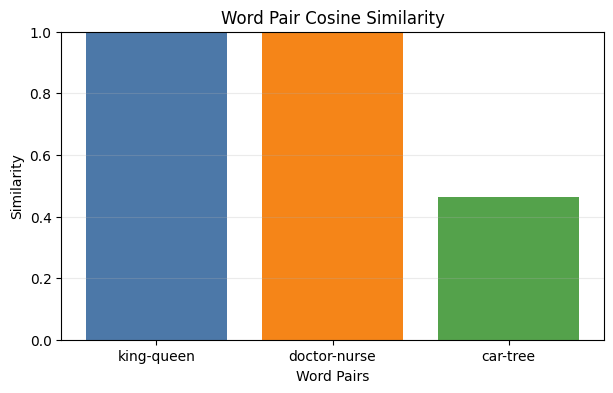

In [6]:
# Visualization: matplotlib bar chart if available, otherwise ASCII bars.
labels = [f"{w1}-{w2}" for w1, w2, _ in results]
scores = [sim for _, _, sim in results]

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 4))
    plt.bar(labels, scores, color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Word Pair Cosine Similarity")
    plt.xlabel("Word Pairs")
    plt.ylabel("Similarity")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.25)
    plt.show()
except Exception:
    print("\nASCII Visualization (matplotlib not available):")
    for label, score in zip(labels, scores):
        bar = '#' * int(score * 40)
        print(f"{label:<15} | {bar} ({score:.4f})")